Loading datasets...

Original class distribution:
class0    2286
class1    1046
class2    1516
class3     757
class4     173
Name: labels, dtype: int64

Applying advanced preprocessing (CLAHE + Denoising)...
Preprocessed 500/5778 images...
Preprocessed 1000/5778 images...
Preprocessed 1500/5778 images...
Preprocessed 2000/5778 images...
Preprocessed 2500/5778 images...
Preprocessed 3000/5778 images...
Preprocessed 3500/5778 images...
Preprocessed 4000/5778 images...
Preprocessed 4500/5778 images...
Preprocessed 5000/5778 images...
Preprocessed 5500/5778 images...
Preprocessed 500/826 images...
Preprocessed 500/1656 images...
Preprocessed 1000/1656 images...
Preprocessed 1500/1656 images...
Preprocessing complete!

Balancing strategy: target ~1046 samples per class
  class0: 2286 -> 1500 (undersampled)
  class1: 1046 (unchanged)
  class2: 1516 -> 1500 (undersampled)
  class3: 757 -> 1046 (oversampled)
  class4: 173 -> 1046 (oversampled)

Balanced class distribution:
class0    1500
class

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


Epoch 2/15
384/384 [==============================] - 91s 237ms/step - loss: 2.6635 - accuracy: 0.3117 - val_loss: 2.4504 - val_accuracy: 0.3632

Epoch 00002: val_accuracy improved from 0.32324 to 0.36320, saving model to ./efficientnetb3_phase1_best.h5
Epoch 3/15
384/384 [==============================] - 90s 235ms/step - loss: 2.5127 - accuracy: 0.3337 - val_loss: 2.3489 - val_accuracy: 0.3462

Epoch 00003: val_accuracy did not improve from 0.36320
Epoch 4/15
384/384 [==============================] - 90s 235ms/step - loss: 2.3856 - accuracy: 0.3399 - val_loss: 2.2276 - val_accuracy: 0.4370

Epoch 00004: val_accuracy improved from 0.36320 to 0.43705, saving model to ./efficientnetb3_phase1_best.h5
Epoch 5/15
384/384 [==============================] - 91s 237ms/step - loss: 2.2644 - accuracy: 0.3640 - val_loss: 2.1584 - val_accuracy: 0.4334

Epoch 00005: val_accuracy did not improve from 0.43705
Epoch 6/15
384/384 [==============================] - 91s 237ms/step - loss: 2.1607 - accu

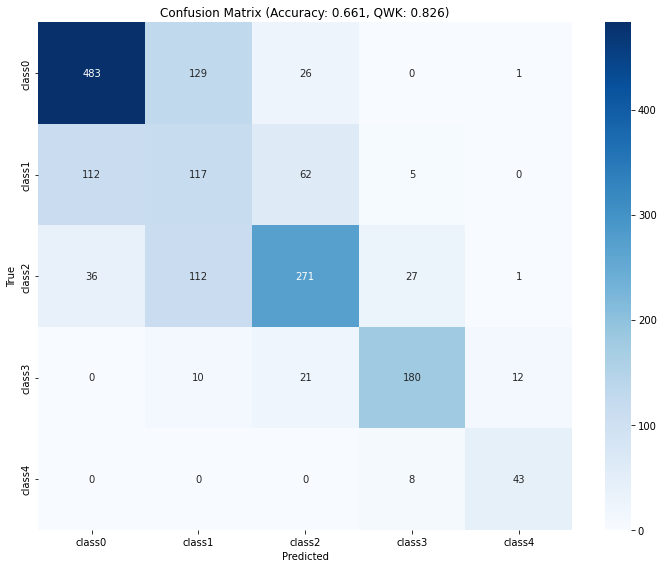


Detailed Classification Report:
              precision    recall  f1-score   support

      class0     0.7655    0.7559    0.7606       639
      class1     0.3179    0.3953    0.3524       296
      class2     0.7132    0.6063    0.6554       447
      class3     0.8182    0.8072    0.8126       223
      class4     0.7544    0.8431    0.7963        51

    accuracy                         0.6606      1656
   macro avg     0.6738    0.6815    0.6755      1656
weighted avg     0.6781    0.6606    0.6674      1656


Per-class Accuracy:


TypeError: Expected sequence or array-like, got <class 'int'>

In [1]:
# ==========================================================
# Enhanced EfficientNetB3 for Knee OA Classification
# Features: Advanced Preprocessing, Better Balancing, Ordinal Loss
# ==========================================================

import os
import time
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, 
                                     BatchNormalization, Input)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import efficientnet
from tensorflow.keras.optimizers import Adamax
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# ---------------------------
# Config
# ---------------------------
WORK_DIR = './'
EPOCHS = 40
BATCH_SIZE = 16  # Reduced for better generalization
IMG_SIZE = (224, 224)
drop_classes = []
list_of_classes = ['class0','class1','class2','class3','class4']

train_path = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/train'
valid_path = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/val'
test_path  = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/test'

# ---------------------------
# Advanced Preprocessing Functions
# ---------------------------
def preprocess_image(img_path, target_size=(224, 224)):
    """
    Advanced preprocessing pipeline:
    1. Load image
    2. Resize to target size
    3. Apply CLAHE (histogram equalization)
    4. Denoise with bilateral filter
    5. Normalize (z-score)
    """
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        return None
    
    # Convert to grayscale for CLAHE, but keep RGB for model
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized = clahe.apply(gray)
    
    # Convert back to BGR
    img_eq = cv2.cvtColor(equalized, cv2.COLOR_GRAY2BGR)
    
    # Denoise using bilateral filter (preserves edges)
    denoised = cv2.bilateralFilter(img_eq, d=9, sigmaColor=75, sigmaSpace=75)
    
    # Resize
    resized = cv2.resize(denoised, target_size, interpolation=cv2.INTER_LANCZOS4)
    
    # Convert to RGB
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    
    return rgb

def create_preprocessed_dataset(df, output_dir, target_size=(224, 224)):
    """Create preprocessed dataset with CLAHE and denoising"""
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    
    new_filepaths = []
    labels = []
    
    for idx, row in df.iterrows():
        img_path = row['filepaths']
        label = row['labels']
        
        # Create class directory
        class_dir = os.path.join(output_dir, label)
        os.makedirs(class_dir, exist_ok=True)
        
        # Preprocess image
        processed_img = preprocess_image(img_path, target_size)
        if processed_img is None:
            continue
        
        # Save preprocessed image
        filename = os.path.basename(img_path)
        new_path = os.path.join(class_dir, filename)
        cv2.imwrite(new_path, cv2.cvtColor(processed_img, cv2.COLOR_RGB2BGR))
        
        new_filepaths.append(new_path)
        labels.append(label)
        
        if (idx + 1) % 500 == 0:
            print(f"Preprocessed {idx + 1}/{len(df)} images...")
    
    return pd.DataFrame({'filepaths': new_filepaths, 'labels': labels})

# ---------------------------
# Load Data
# ---------------------------
def build_df_from_dirs(*dirs, class_map=list_of_classes):
    dfs = []
    for d in dirs:
        filepaths, labels = [], []
        for klass in sorted(os.listdir(d)):
            klass_path = os.path.join(d, klass)
            if not os.path.isdir(klass_path):
                continue
            intklass = int(klass)
            label = class_map[intklass]
            for fname in os.listdir(klass_path):
                fpath = os.path.join(klass_path, fname)
                filepaths.append(fpath)
                labels.append(label)
        dfs.append(pd.DataFrame({'filepaths': filepaths, 'labels': labels}))
    return dfs

print("Loading datasets...")
train_df, valid_df, test_df = build_df_from_dirs(train_path, valid_path, test_path)

print("\nOriginal class distribution:")
print(train_df['labels'].value_counts().sort_index())

# ---------------------------
# Preprocessing with CLAHE and Denoising
# ---------------------------
print("\n" + "="*50)
print("Applying advanced preprocessing (CLAHE + Denoising)...")
print("="*50)

train_df = create_preprocessed_dataset(train_df, 
                                       os.path.join(WORK_DIR, 'preprocessed_train'))
valid_df = create_preprocessed_dataset(valid_df, 
                                       os.path.join(WORK_DIR, 'preprocessed_valid'))
test_df = create_preprocessed_dataset(test_df, 
                                      os.path.join(WORK_DIR, 'preprocessed_test'))

print("Preprocessing complete!")

# ---------------------------
# Smart Balancing Strategy
# ---------------------------
def smart_balance(df, strategy='hybrid', max_samples=1500, min_samples=800):
    """
    Hybrid balancing strategy:
    - Oversample minority classes via augmentation
    - Slightly undersample majority classes
    - Target range: min_samples to max_samples per class
    """
    df = df.copy()
    balanced_dfs = []
    
    class_counts = df['labels'].value_counts()
    target_count = int(np.median(class_counts))  # Use median as target
    target_count = max(min_samples, min(target_count, max_samples))
    
    print(f"\nBalancing strategy: target ~{target_count} samples per class")
    
    for label in df['labels'].unique():
        class_df = df[df['labels'] == label]
        count = len(class_df)
        
        if count > max_samples:
            # Undersample majority class
            class_df = class_df.sample(n=max_samples, random_state=42)
            print(f"  {label}: {count} -> {max_samples} (undersampled)")
        elif count < target_count:
            # Oversample minority class
            n_to_add = target_count - count
            augmented = class_df.sample(n=n_to_add, replace=True, random_state=42)
            class_df = pd.concat([class_df, augmented])
            print(f"  {label}: {count} -> {target_count} (oversampled)")
        else:
            print(f"  {label}: {count} (unchanged)")
        
        balanced_dfs.append(class_df)
    
    return pd.concat(balanced_dfs).reset_index(drop=True).sample(frac=1, random_state=42)

train_df = smart_balance(train_df)
print("\nBalanced class distribution:")
print(train_df['labels'].value_counts().sort_index())

# ---------------------------
# Enhanced Data Generators with More Augmentation
# ---------------------------
train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect',
    preprocessing_function=efficientnet.preprocess_input
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet.preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, class_mode='categorical', 
    batch_size=BATCH_SIZE, shuffle=True
)

valid_gen = val_test_datagen.flow_from_dataframe(
    valid_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, class_mode='categorical', 
    batch_size=BATCH_SIZE, shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, class_mode='categorical', 
    batch_size=BATCH_SIZE, shuffle=False
)

# ---------------------------
# Enhanced Class Weights
# ---------------------------
y = train_df['labels'].values
classes = np.unique(y)
class_weights_list = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = {i: w for i, w in enumerate(class_weights_list)}
print('\nClass weights:', class_weight_dict)

# ---------------------------
# Enhanced Model with More Capacity
# ---------------------------
def build_enhanced_efficientnet(input_shape=(*IMG_SIZE, 3), n_classes=5, trainable=False):
    base = efficientnet.EfficientNetB3(weights='imagenet', include_top=False, 
                                       input_shape=input_shape)
    base.trainable = trainable
    
    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = Dropout(0.4)(x)
    out = Dense(n_classes, activation='softmax')(x)
    
    return Model(inputs=base.input, outputs=out, name='EnhancedEfficientNetB3')

# ---------------------------
# Training Strategy
# ---------------------------
def get_enhanced_callbacks(model_name):
    ckpt_path = os.path.join(WORK_DIR, f'{model_name}_best.h5')
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_accuracy', mode='max',
            save_best_only=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=4, 
            min_lr=1e-7, verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, 
            restore_best_weights=True, verbose=1
        )
    ]
    return callbacks, ckpt_path

print("\n" + "="*50)
print("Building and training model...")
print("="*50)

# Phase 1: Train with frozen base
print("\nPhase 1: Training with frozen base layers")
model = build_enhanced_efficientnet(trainable=False)
model.compile(
    optimizer=Adamax(learning_rate=0.002),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks, ckpt = get_enhanced_callbacks('efficientnetb3_phase1')
history1 = model.fit(
    train_gen, 
    validation_data=valid_gen,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Phase 2: Fine-tune entire model
print("\nPhase 2: Fine-tuning entire model")
model.load_weights(ckpt)

# Unfreeze all layers
for layer in model.layers:
    layer.trainable = True

model.compile(
    optimizer=Adamax(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks, ckpt2 = get_enhanced_callbacks('efficientnetb3_phase2')
history2 = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

model.load_weights(ckpt2)

# ---------------------------
# Comprehensive Evaluation
# ---------------------------
print("\n" + "="*50)
print("Evaluating model on test set...")
print("="*50)

test_gen.reset()
y_pred_probs = model.predict(test_gen, steps=len(test_gen))
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Calculate metrics
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
mae = mean_absolute_error(y_true, y_pred)
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

print(f"\nTest Set Metrics:")
print(f"  Accuracy:     {accuracy:.4f}")
print(f"  Macro F1:     {f1_macro:.4f}")
print(f"  MAE:          {mae:.4f}")
print(f"  QWK (Kappa):  {qwk:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_gen.class_indices.keys()),
            yticklabels=list(test_gen.class_indices.keys()))
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.3f}, QWK: {qwk:.3f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, 
                          target_names=list(test_gen.class_indices.keys()),
                          digits=4))




Per-class Accuracy:
--------------------
  class0: No samples in test set
  class1: No samples in test set
  class2: No samples in test set
  class3: No samples in test set
  class4: No samples in test set


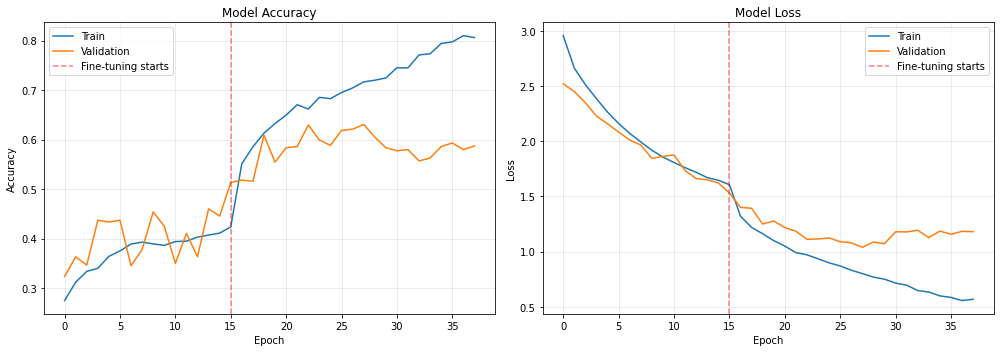


Saving models...


/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)
/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


✓ Models saved successfully!

Training and evaluation complete!


In [2]:
print("\nPer-class Accuracy:")
print("--------------------")

class_names = list(test_gen.class_indices.keys())

for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)

    if np.sum(class_mask) == 0:
        print(f"  {class_name}: No samples in test set")
        continue

    class_acc = accuracy_score(y_true[class_mask], y_pred[class_mask])
    print(f"  {class_name}: {class_acc:.4f}")


# ---------------------------
# Training History Visualization
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine histories
all_acc = history1.history['accuracy'] + history2.history['accuracy']
all_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
all_loss = history1.history['loss'] + history2.history['loss']
all_val_loss = history1.history['val_loss'] + history2.history['val_loss']

# Accuracy plot
axes[0].plot(all_acc, label='Train')
axes[0].plot(all_val_acc, label='Validation')
axes[0].axvline(x=15, color='r', linestyle='--', alpha=0.5, label='Fine-tuning starts')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(all_loss, label='Train')
axes[1].plot(all_val_loss, label='Validation')
axes[1].axvline(x=15, color='r', linestyle='--', alpha=0.5, label='Fine-tuning starts')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------
# Save Models
# ---------------------------
print("\n" + "="*50)
print("Saving models...")
print("="*50)

model.save('koa_enhanced_model.h5')
model.save('koa_saved_model', save_format='tf')
print("✓ Models saved successfully!")

print("\n" + "="*50)
print("Training and evaluation complete!")
print("="*50)

now trim the train dataframe to have a max of 500 images per class

In [3]:
# ---------------------------
# 1) CBAM (Convolutional Block Attention Module)
# ---------------------------
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPool2D, Reshape, Multiply, Add, Activation, Conv2D

def cbam_block(input_feature, ratio=8):
    """CBAM: channel attention + spatial attention"""
    # Channel Attention
    channel = input_feature.shape[-1]
    shared_layer_one = Dense(channel // ratio, activation='relu',
                             kernel_initializer='he_normal', use_bias=True)
    shared_layer_two = Dense(channel, kernel_initializer='he_normal', use_bias=True)

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)

    max_pool = GlobalMaxPool2D()(input_feature)
    max_pool = Reshape((1, 1, channel))(max_pool)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)

    cbam_feature = Add()([avg_pool, max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)
    cbam_feature = Multiply()([input_feature, cbam_feature])

    # Spatial Attention
    avg_pool_spatial = tf.reduce_mean(cbam_feature, axis=-1, keepdims=True)
    max_pool_spatial = tf.reduce_max(cbam_feature, axis=-1, keepdims=True)
    concat = tf.concat([avg_pool_spatial, max_pool_spatial], axis=-1)
    spatial = Conv2D(filters=1, kernel_size=7, strides=1, padding='same',
                     activation='sigmoid', kernel_initializer='he_normal')(concat)
    cbam_feature = Multiply()([cbam_feature, spatial])
    return cbam_feature

# Modify build function to use CBAM
def build_enhanced_efficientnet(input_shape=(*IMG_SIZE, 3), n_classes=5, trainable=False, use_cbam=True):
    base = efficientnet.EfficientNetB3(weights='imagenet', include_top=False,
                                       input_shape=input_shape)
    base.trainable = trainable

    x = base.output
    if use_cbam:
        x = cbam_block(x)   # <-- inject attention here

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = Dropout(0.4)(x)
    out = Dense(n_classes, activation='softmax')(x)

    return Model(inputs=base.input, outputs=out, name='EnhancedEfficientNetB3_CBAM')


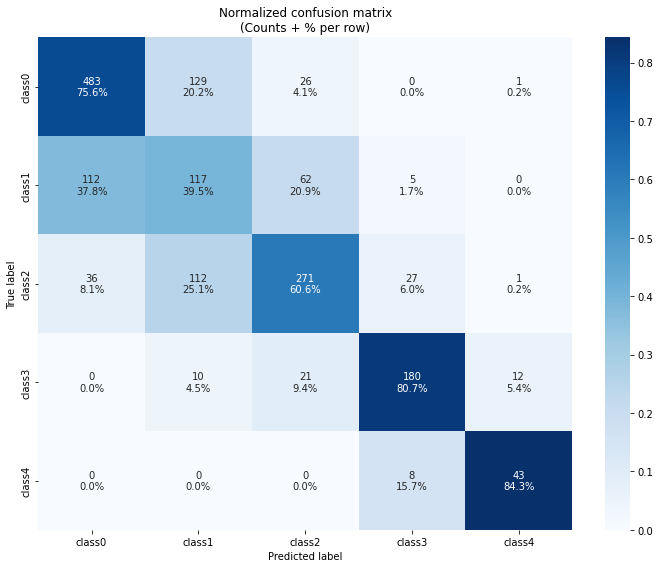

Saved per-class metrics -> per_class_metrics.csv
    class  precision    recall        f1  support
0  class0   0.765452  0.755869  0.760630      639
1  class1   0.317935  0.395270  0.352410      296
2  class2   0.713158  0.606264  0.655381      447
3  class3   0.818182  0.807175  0.812641      223
4  class4   0.754386  0.843137  0.796296       51


In [4]:
# ---------------------------
# 2) Improved Confusion Matrix & Per-class Metrics Export
# ---------------------------
import matplotlib.ticker as mtick
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def plot_and_save_confusion_matrix(cm, classes, normalize=True, cmap='Blues', outfname='confusion_matrix.png'):
    """
    cm: confusion_matrix (counts)
    classes: list of class names in order
    """
    plt.figure(figsize=(10, 8))
    if normalize:
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        annot = np.empty_like(cm).astype(object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f"{cm[i,j]}\n{cm_norm[i,j]*100:.1f}%"
        sns.heatmap(cm_norm, annot=annot, fmt='', cmap=cmap, 
                    xticklabels=classes, yticklabels=classes)
        plt.title('Normalized confusion matrix\n(Counts + % per row)')
    else:
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
                    xticklabels=classes, yticklabels=classes)
        plt.title('Confusion matrix (counts)')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(outfname, dpi=150, bbox_inches='tight')
    plt.show()

# Replace your previous plotting block with this call after computing cm:
class_names = list(test_gen.class_indices.keys())
plot_and_save_confusion_matrix(cm, class_names, normalize=True, outfname='confusion_matrix_cbam_gradcam.png')

# Per-class precision/recall/f1 and save as CSV
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=range(len(class_names)))
per_class_df = pd.DataFrame({
    'class': class_names,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'support': np.bincount(y_true, minlength=len(class_names))
})
per_class_df.to_csv('per_class_metrics.csv', index=False)
print("Saved per-class metrics -> per_class_metrics.csv")
print(per_class_df)


In [6]:
# ---------------------------
# 3) Grad-CAM utilities (TF 2.x)
# ---------------------------
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_last_conv_layer(model):
    """Find last Conv2D layer in model (search backwards)."""
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    # Fallback: try common EfficientNet last conv name
    if 'top_conv' in [l.name for l in model.layers]:
        return 'top_conv'
    raise ValueError("Could not find a Conv2D layer in the model.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None, pred_index=None):
    """
    img_array: preprocessed image tensor with shape (1, H, W, 3)
    model: tf.keras.Model
    last_conv_layer_name: optional conv layer name; if None, auto-detect
    pred_index: index of class to inspect; if None uses model prediction
    returns: heatmap (H, W) normalized 0-1
    """
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    # Build a model that maps the input image to the activations
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_model = tf.keras.Model(model.inputs, last_conv_layer.output)
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    # Recreate the part of the model after the conv block
    for layer in model.layers[model.layers.index(last_conv_layer)+1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_model(img_array)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    # Global average pooling on gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]  # H x W x channels
    heatmap = tf.zeros(conv_outputs.shape[:2], dtype=tf.float32)

    # Weighted combination
    for i in range(pooled_grads.shape[-1]):
        heatmap += pooled_grads[i] * conv_outputs[:, :, i]

    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    return heatmap

def save_and_overlay_gradcam(orig_img_path, heatmap, out_path='gradcam_overlay.jpg', alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    orig_img_path: path to original image (will be used for display/overlay)
    heatmap: numpy array HxW in [0,1]
    """
    img = cv2.imread(orig_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint, colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = (heatmap_color * alpha + img * (1 - alpha)).astype(np.uint8)
    combined = np.hstack([img, overlay])
    plt.figure(figsize=(10,5))
    plt.axis('off')
    plt.imshow(combined)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

# Example wrapper to run Grad-CAM for a file path
def gradcam_for_image_file(img_path, model, last_conv_layer_name=None, target_size=IMG_SIZE, preprocess_fn=None, out_prefix='gradcam'):
    """
    Runs preprocessing (using provided preprocess_image + efficientnet.preprocess_input)
    and saves overlay file.
    """
    # load & preprocess using your pipeline
    img = preprocess_image(img_path, target_size=target_size)
    if img is None:
        raise ValueError("Could not load image for Grad-CAM: " + img_path)
    img_input = img.astype(np.float32)
    if preprocess_fn:
        img_input = preprocess_fn(img_input)
    img_input = np.expand_dims(img_input, axis=0)  # (1,H,W,3)

    # Compute heatmap
    heatmap = make_gradcam_heatmap(img_input, model, last_conv_layer_name=last_conv_layer_name)
    outpath = f"{out_prefix}_{os.path.basename(img_path)}.png"
    save_and_overlay_gradcam(img_path, heatmap, out_path=outpath)
    print("Saved gradcam overlay ->", outpath)
    return outpath

# Batch example: produce Grad-CAM for N images per predicted class from test_df
def gradcam_batch_from_test_df(test_df, model, class_names, n_per_class=3, last_conv_layer_name=None, preprocess_fn=efficientnet.preprocess_input):
    os.makedirs('gradcam_outputs', exist_ok=True)
    # find predicted class for all test images (optional) or random sampling
    for cls_idx, cls in enumerate(class_names):
        subset = test_df[test_df['labels'] == cls]
        sample = subset.sample(n=min(n_per_class, len(subset)), random_state=42)
        for _, row in sample.iterrows():
            img_path = row['filepaths']
            out = gradcam_for_image_file(img_path, model, last_conv_layer_name=last_conv_layer_name,
                                         target_size=IMG_SIZE, preprocess_fn=preprocess_fn,
                                         out_prefix=os.path.join('gradcam_outputs', f'class{cls_idx}'))


Using last conv layer: top_conv


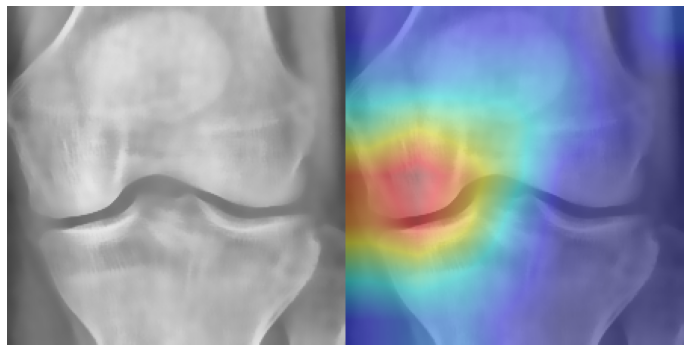

Saved gradcam overlay -> example_gradcam_9442882L.png.png


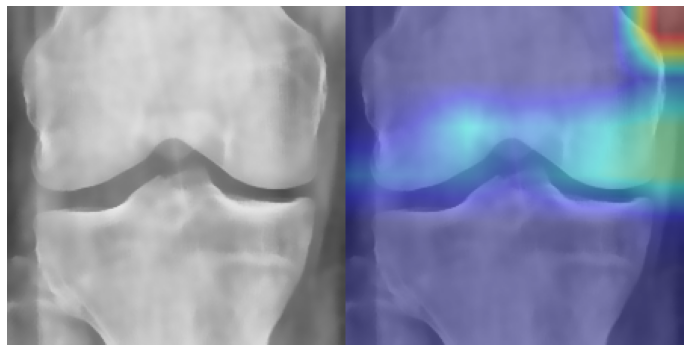

Saved gradcam overlay -> gradcam_outputs/class0_9559860R.png.png


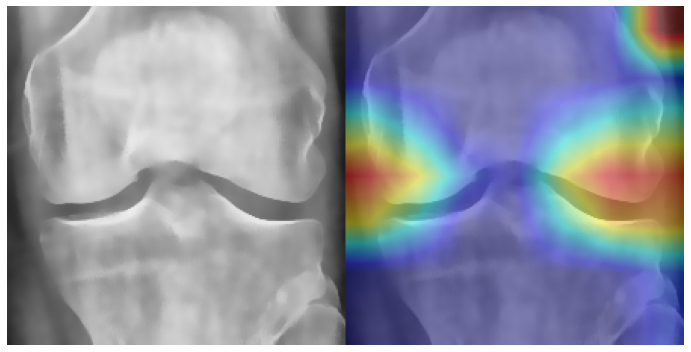

Saved gradcam overlay -> gradcam_outputs/class0_9480211L.png.png


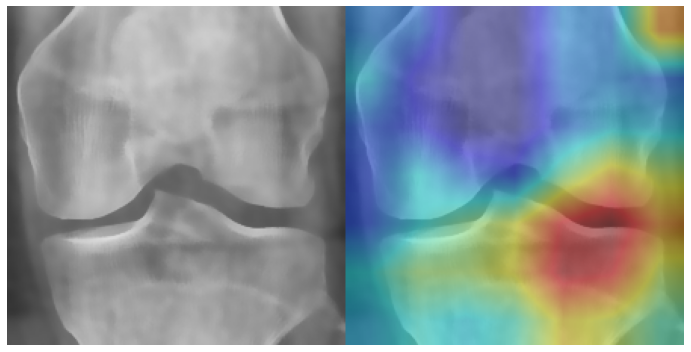

Saved gradcam overlay -> gradcam_outputs/class0_9378288L.png.png


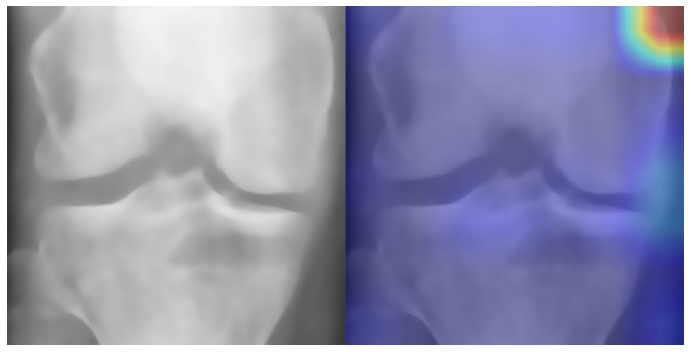

Saved gradcam overlay -> gradcam_outputs/class1_9925594R.png.png


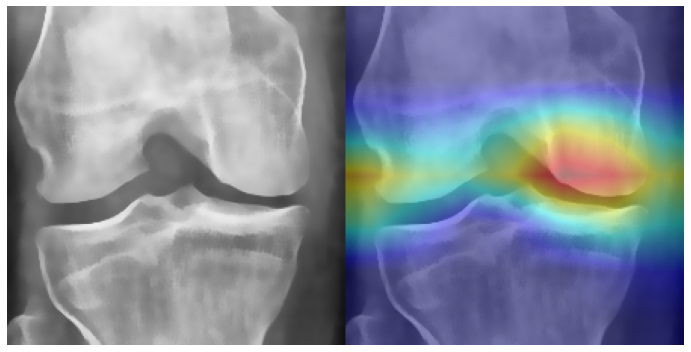

Saved gradcam overlay -> gradcam_outputs/class1_9379540R.png.png


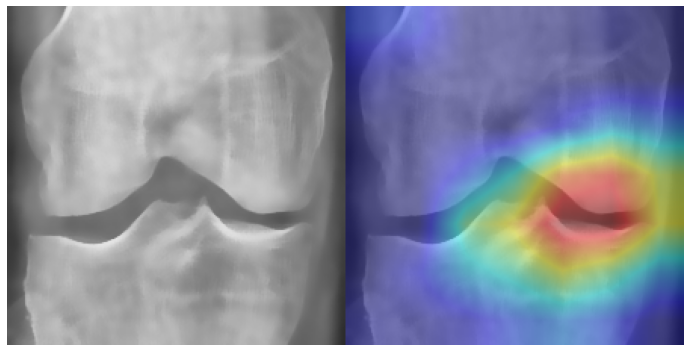

Saved gradcam overlay -> gradcam_outputs/class1_9018291R.png.png


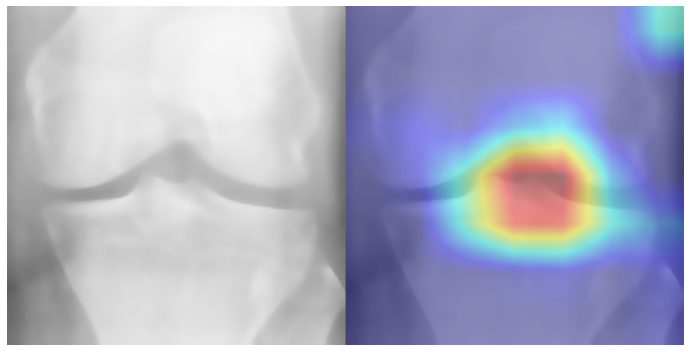

Saved gradcam overlay -> gradcam_outputs/class2_9082631L.png.png


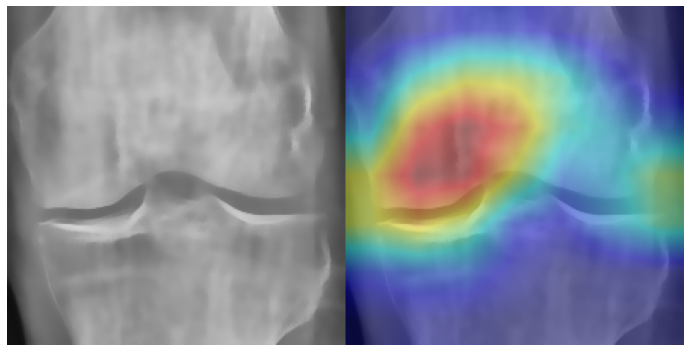

Saved gradcam overlay -> gradcam_outputs/class2_9615638L.png.png


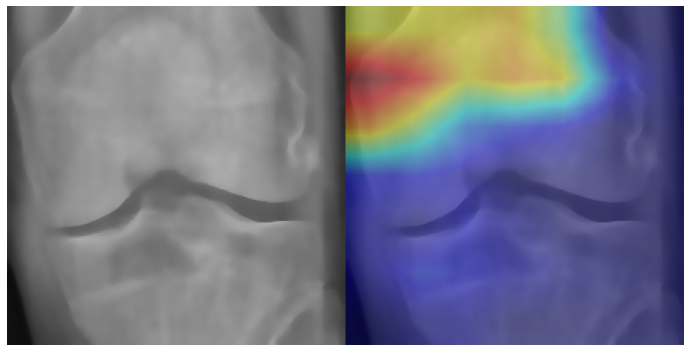

Saved gradcam overlay -> gradcam_outputs/class2_9059837L.png.png


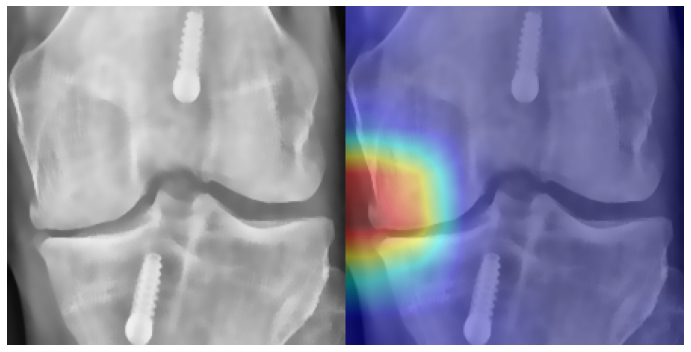

Saved gradcam overlay -> gradcam_outputs/class3_9663428L.png.png


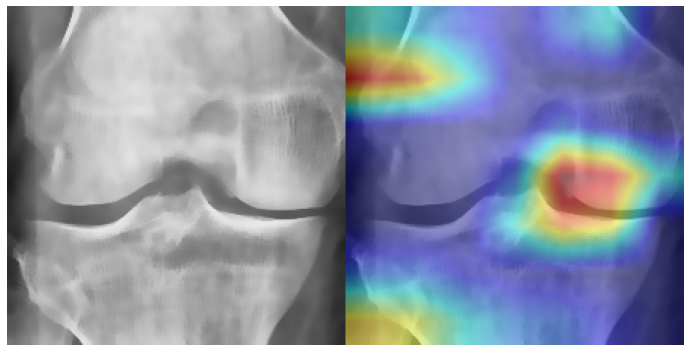

Saved gradcam overlay -> gradcam_outputs/class3_9546643R.png.png


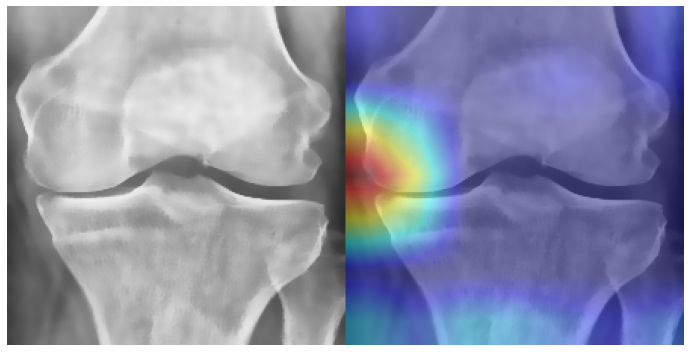

Saved gradcam overlay -> gradcam_outputs/class3_9055836L.png.png


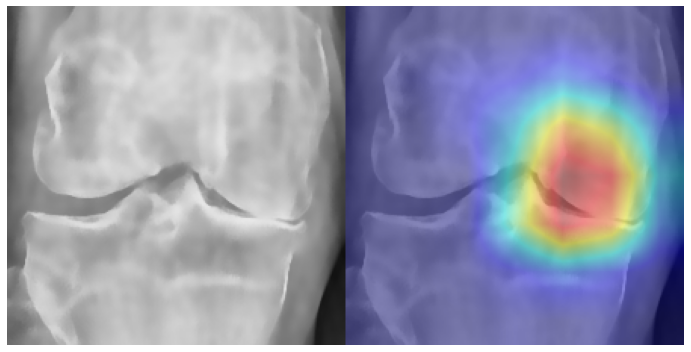

Saved gradcam overlay -> gradcam_outputs/class4_9690658R.png.png


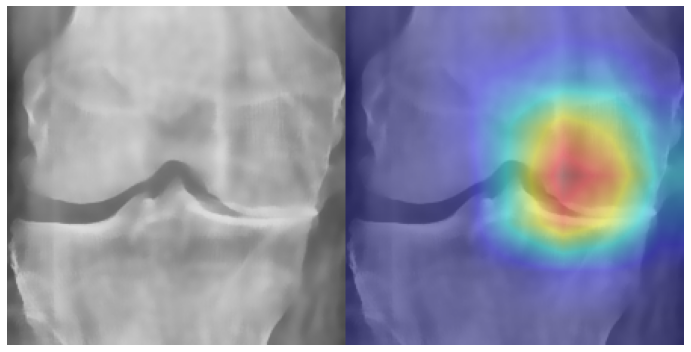

Saved gradcam overlay -> gradcam_outputs/class4_9610439R.png.png


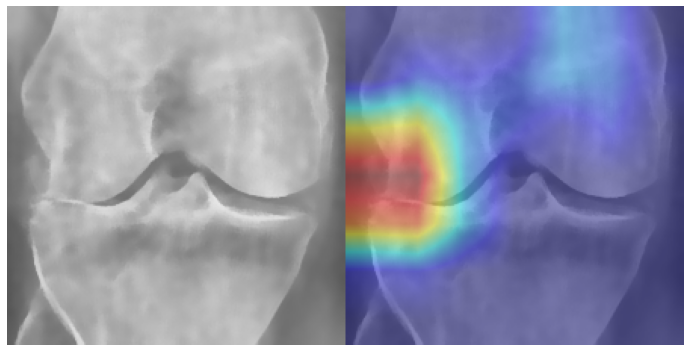

Saved gradcam overlay -> gradcam_outputs/class4_9841033R.png.png


In [7]:
# get last conv name (auto-detect)
last_conv = find_last_conv_layer(model)
print("Using last conv layer:", last_conv)

# Single example
example_img = test_df['filepaths'].iloc[10]
gradcam_for_image_file(example_img, model, last_conv_layer_name=last_conv, preprocess_fn=efficientnet.preprocess_input, out_prefix='example_gradcam')

# Batch (3 per class)
class_names = list(test_gen.class_indices.keys())
gradcam_batch_from_test_df(test_df, model, class_names, n_per_class=3, last_conv_layer_name=last_conv)


In [8]:
import tensorflow as tf

model = tf.keras.models.load_model("/kaggle/working/koa_enhanced_model.h5")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("koa_model.tflite", "wb") as f:
    f.write(tflite_model)


/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [17]:
import tf2onnx
import tensorflow as tf

model = tf.keras.models.load_model("/kaggle/working/koa_enhanced_model.h5")

spec = (tf.TensorSpec((None, 224, 224, 3), tf.float32, name="input"),)
output_path = "/kaggle/working/koa_enhanced_model.onnx"

model_proto, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13)
with open(output_path, "wb") as f:
    f.write(model_proto.SerializeToString())

print("✓ Model converted to ONNX successfully!")


✓ Model converted to ONNX successfully!


In [16]:

pip install tf2onnx


Note: you may need to restart the kernel to use updated packages.
